<a href="https://colab.research.google.com/github/amoghsharma6996/AmoghKumarSharma23BDS0063/blob/main/EDA_Phase1_Amogh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA on Student Performance Dataset (Phase 1)

**Name:** Amogh Kumar Sharma
**Reg No:** 23BDS0063

Dataset: [student-mat.csv](https://raw.githubusercontent.com/salemprakash/EDA/main/Data/student-mat.csv) — Student Math Performance dataset.

This notebook covers all the Phase 1 tasks:
1. Loading the dataset
2. Basic statistical analysis
3. Handling missing data
4. Data cleaning
5. Data transformation
6. Univariate analysis
7. Bivariate analysis
8. Multivariate analysis


## 0. Importing required libraries
Basic libraries needed for loading data, doing stats, and plotting.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline


## 1. Loading the Dataset
Reading the CSV file directly from the GitHub raw link given in the assignment.

In [12]:
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/student-mat.csv"

df = pd.read_csv("student-mat.csv")

# checking first 5 rows to see if it loaded properly
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [13]:
# checking shape of dataset -> (rows, columns)
print("Shape of dataset:", df.shape)

# checking column names
print("\nColumn names:")
print(df.columns.tolist())


Shape of dataset: (395, 33)

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [14]:
# quick info about datatypes and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         393 non-null    object
 2   age         395 non-null    int64 
 3   address     394 non-null    object
 4   famsize     394 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   393 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

## 2. Applying Basic Statistical Analysis
Using `describe()` to get mean, std, min, max, quartiles etc. for the numeric columns.
Also checking value counts for a few categorical columns.

In [15]:
# statistical summary of all numeric columns
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [16]:
# describe() for categorical columns too
df.describe(include='object')


,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
count,395,393,394,394,395,395,395,395,395,393,395,395,395,395,395,395,395
unique,2,2,3,2,3,5,5,4,3,2,2,2,2,2,2,2,2
top,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,yes,yes,yes,yes,no
freq,349,208,304,280,348,141,217,145,273,343,242,214,201,314,375,329,263


In [17]:
# checking some individual stats for the final grade column (G3)
print("Mean of G3:", df['G3'].mean())
print("Median of G3:", df['G3'].median())
print("Mode of G3:", df['G3'].mode()[0])
print("Std Dev of G3:", df['G3'].std())
print("Variance of G3:", df['G3'].var())


Mean of G3: 10.415189873417722
Median of G3: 11.0
Mode of G3: 10
Std Dev of G3: 4.5814426109978434
Variance of G3: 20.989616397866737


## 3. Handling Missing Data
Checking if there are any missing/null values in the dataset. This particular dataset is usually clean
(no missing values), but we still check properly instead of assuming.

In [18]:
# checking null values column-wise
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal missing values in dataset:", df.isnull().sum().sum())


Missing values per column:
school        0
sex           2
age           0
address       1
famsize       1
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     2
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Total missing values in dataset: 6


In [19]:
# Even though this dataset does not have missing values,
# writing the handling code anyway so the pipeline is complete
# for numeric columns -> fill missing with median.
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# for categorical columns -> fill missing with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# confirming no missing values remain
print("Missing values after handling:", df.isnull().sum().sum())


Missing values after handling: 0


## 4. Data Cleaning
Checking for duplicate rows and any obvious inconsistencies in the data.

In [20]:
# checking for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

# dropping duplicates if any
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Number of duplicate rows: 0
Shape after removing duplicates: (395, 33)


In [21]:
# checking unique values in some categorical columns to spot any weird/inconsistent entries
for col in ['school', 'sex', 'address', 'famsize', 'Pstatus', 'higher', 'internet']:
    print(col, "->", df[col].unique())


school -> ['GP' 'MS']
sex -> ['F' 'M']
address -> ['U' 'R' '?']
famsize -> ['GT3' 'LE3']
Pstatus -> ['A' 'T' '?']
higher -> ['yes' 'no']
internet -> ['no' 'yes']


In [22]:
# stripping any extra spaces from column names,
df.columns = df.columns.str.strip()

# resetting index after dropping duplicates so index stays continuous
df = df.reset_index(drop=True)


## 5. Data Transformation
Creating a couple of new/derived columns and encoding categorical variables so that they
can be used later for analysis (like correlation, multivariate plots etc.)

In [23]:
# Grades G1, G2, G3 are on a 0-20 scale, adding an average grade column
df['avg_grade'] = (df['G1'] + df['G2'] + df['G3']) / 3
# just a simple bucketing: Low / Medium / High
def grade_bucket(g):
    if g < 10:
        return 'Low'
    elif g < 15:
        return 'Medium'
    else:
        return 'High'

df['performance'] = df['G3'].apply(grade_bucket)

df[['G1', 'G2', 'G3', 'avg_grade', 'performance']].head()


,G1,G2,G3,avg_grade,performance
0,5,6,6,5.666667,Low
1,5,5,6,5.333333,Low
2,7,8,10,8.333333,Medium
3,15,14,15,14.666667,High
4,6,10,10,8.666667,Medium


In [24]:
# label encoding some binary categorical columns (yes/no -> 1/0) so they're easier to use in plots/corr
binary_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

for col in binary_cols:
    df[col + '_enc'] = df[col].map({'yes': 1, 'no': 0})

df[binary_cols + [c + '_enc' for c in binary_cols]].head()


,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,schoolsup_enc,famsup_enc,paid_enc,activities_enc,nursery_enc,higher_enc,internet_enc,romantic_enc
0,yes,no,no,no,yes,yes,no,no,1,0,0,0,1,1,0,0
1,no,yes,no,no,no,yes,yes,no,0,1,0,0,0,1,1,0
2,yes,no,yes,no,yes,yes,yes,no,1,0,1,0,1,1,1,0
3,no,yes,yes,yes,yes,yes,yes,yes,0,1,1,1,1,1,1,1
4,no,yes,yes,no,yes,yes,no,no,0,1,1,0,1,1,0,0


## 6. Univariate Analysis
Looking at individual columns one at a time. Using histograms, count plots and a box plot.

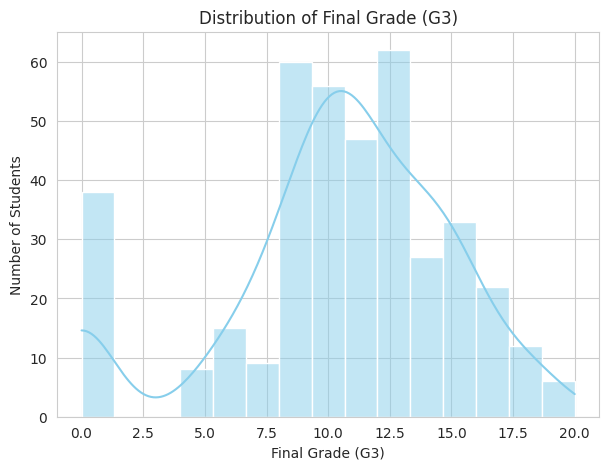

In [25]:
# Plot 1: Histogram of final grade (G3)
plt.figure(figsize=(7,5))
sns.histplot(df['G3'], bins=15, kde=True, color='skyblue')
plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.show()


/tmp/ipykernel_2933/2828327130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette='pastel')


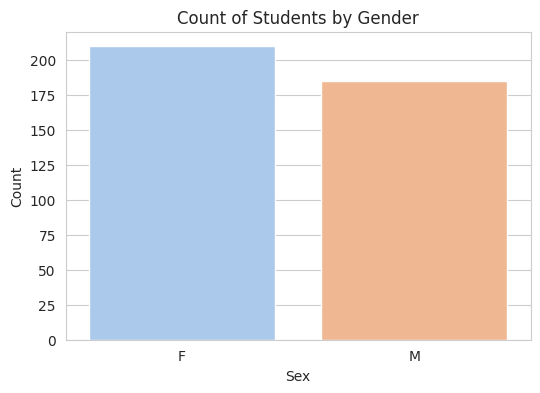

In [26]:
# Plot 2: Count plot of students by sex
plt.figure(figsize=(6,4))
sns.countplot(x='sex', data=df, palette='pastel')
plt.title("Count of Students by Gender")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()


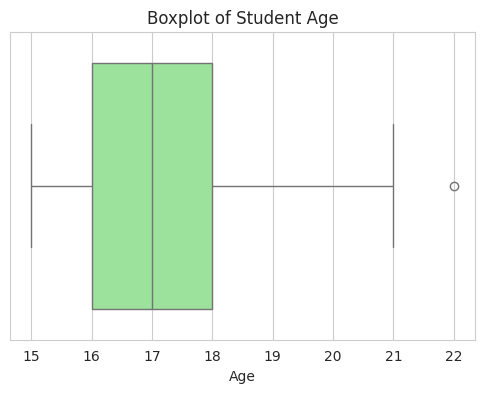

In [27]:
# Plot 3: Box plot for age to check spread and outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df['age'], color='lightgreen')
plt.title("Boxplot of Student Age")
plt.xlabel("Age")
plt.show()


/tmp/ipykernel_2933/1866400911.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='studytime', data=df, palette='muted')


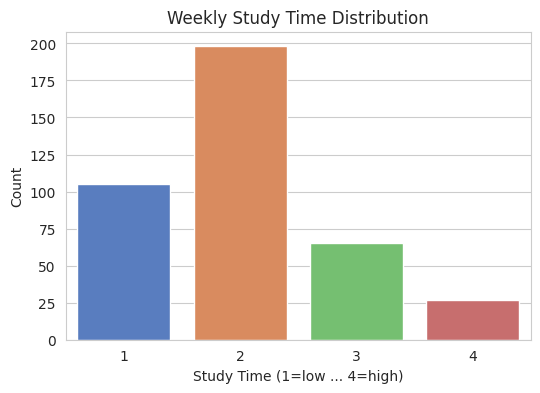

In [28]:
# Plot 4 (extra): Distribution of weekly study time
plt.figure(figsize=(6,4))
sns.countplot(x='studytime', data=df, palette='muted')
plt.title("Weekly Study Time Distribution")
plt.xlabel("Study Time (1=low ... 4=high)")
plt.ylabel("Count")
plt.show()


## 7. Bivariate Analysis
Looking at relationship between two variables at a time.

/tmp/ipykernel_2933/3700648513.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='studytime', y='G3', data=df, palette='Set2')


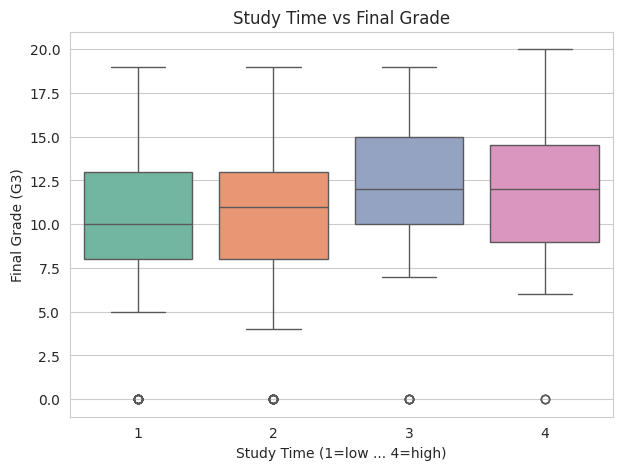

In [29]:
# Plot 1: Study time vs Final grade
plt.figure(figsize=(7,5))
sns.boxplot(x='studytime', y='G3', data=df, palette='Set2')
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time (1=low ... 4=high)")
plt.ylabel("Final Grade (G3)")
plt.show()


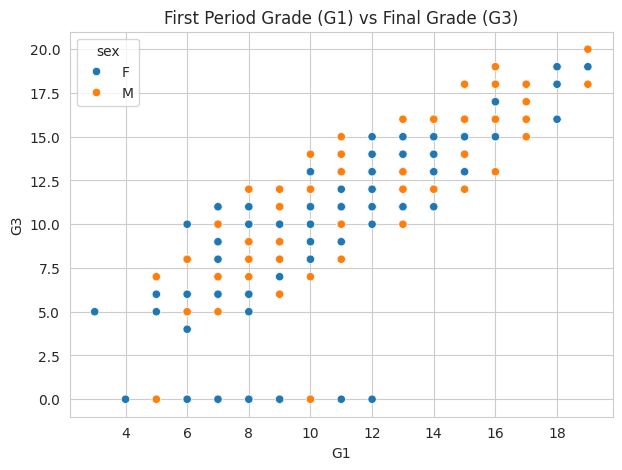

In [30]:
# Plot 2: Scatter plot - G1 vs G3 (first period grade vs final grade)
plt.figure(figsize=(7,5))
sns.scatterplot(x='G1', y='G3', data=df, hue='sex')
plt.title("First Period Grade (G1) vs Final Grade (G3)")
plt.xlabel("G1")
plt.ylabel("G3")
plt.show()


/tmp/ipykernel_2933/2626768506.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pstatus', y='G3', data=df, palette='coolwarm', ci=None)
/tmp/ipykernel_2933/2626768506.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pstatus', y='G3', data=df, palette='coolwarm', ci=None)


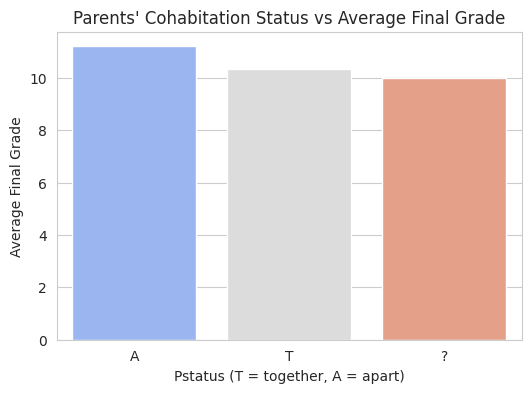

In [31]:
# Plot 3: Average final grade by parents' cohabitation status
plt.figure(figsize=(6,4))
sns.barplot(x='Pstatus', y='G3', data=df, palette='coolwarm', ci=None)
plt.title("Parents' Cohabitation Status vs Average Final Grade")
plt.xlabel("Pstatus (T = together, A = apart)")
plt.ylabel("Average Final Grade")
plt.show()


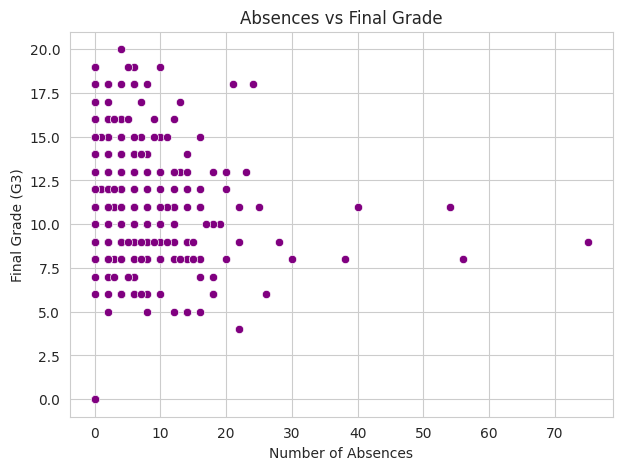

In [32]:
# Plot 4 (extra): Correlation between absences and final grade
plt.figure(figsize=(7,5))
sns.scatterplot(x='absences', y='G3', data=df, color='purple')
plt.title("Absences vs Final Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade (G3)")
plt.show()


## 8. Multivariate Analysis
Looking at relationships between 3 or more variables together.

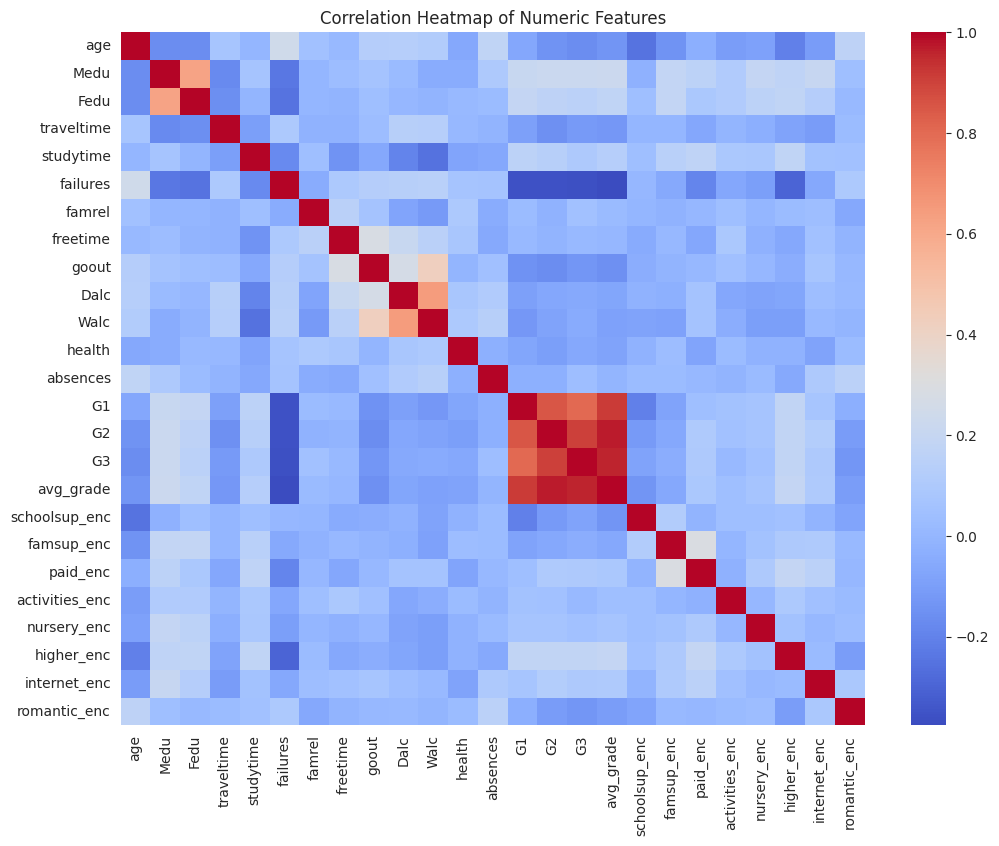

In [33]:
# Plot 1: Correlation heatmap of numeric columns
plt.figure(figsize=(12,9))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


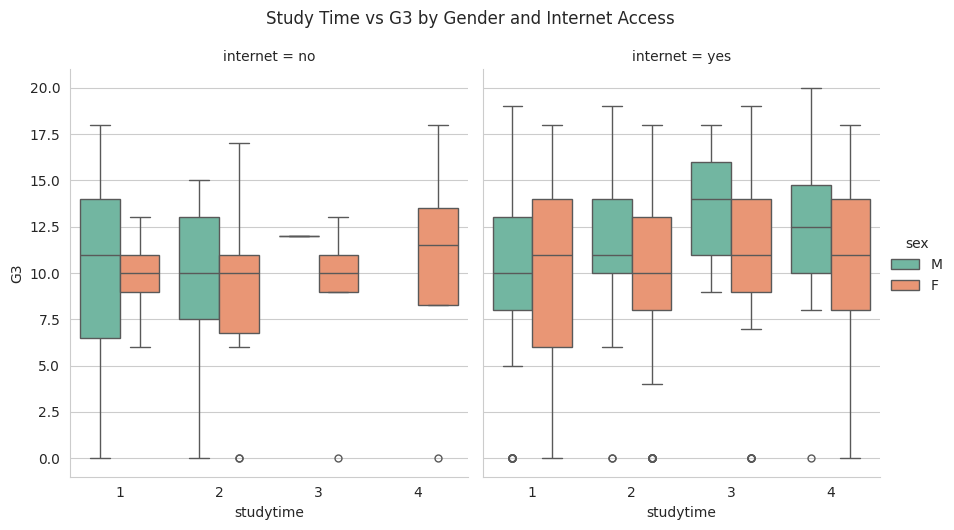

In [34]:
# Plot 2: Study time vs G3, split by gender (hue) and internet access (col)
g = sns.catplot(x='studytime', y='G3', hue='sex', col='internet',
                 data=df, kind='box', palette='Set2', height=5, aspect=0.9)
g.fig.suptitle("Study Time vs G3 by Gender and Internet Access", y=1.05)
plt.show()


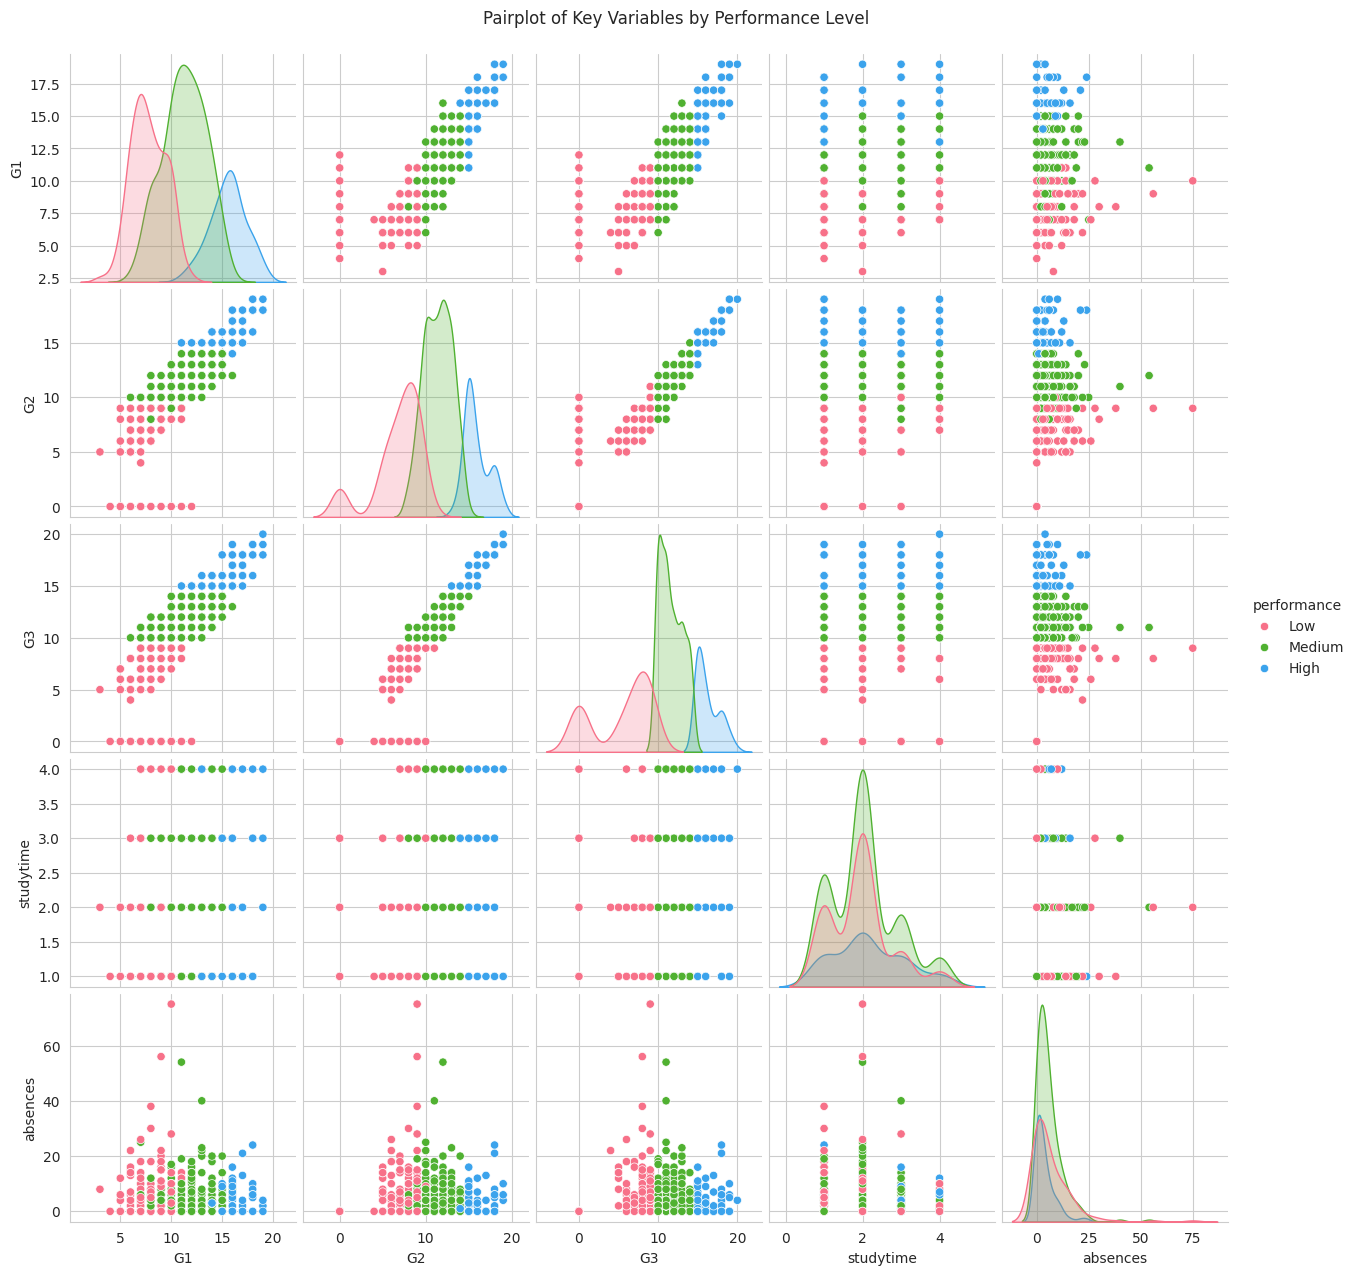

In [35]:
# Plot 3: Pairplot of a few important numeric columns, colored by performance bucket
cols_to_plot = ['G1', 'G2', 'G3', 'studytime', 'absences', 'performance']
sns.pairplot(df[cols_to_plot], hue='performance', palette='husl')
plt.suptitle("Pairplot of Key Variables by Performance Level", y=1.02)
plt.show()


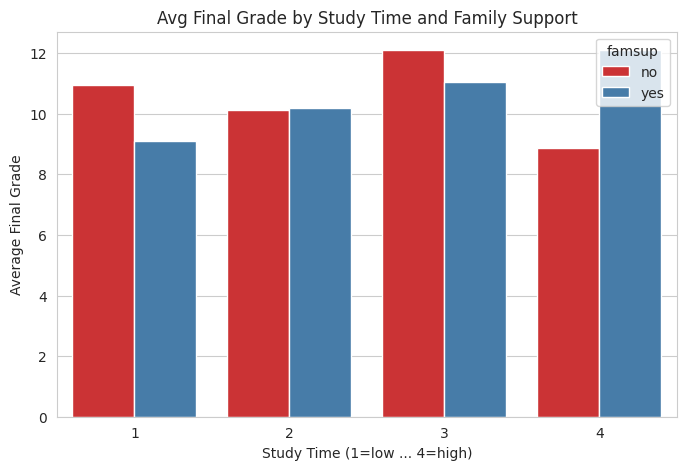

In [36]:
# Plot 4 : Avg final grade by study time and family support, grouped bar chart
pivot_df = df.groupby(['studytime', 'famsup'])['G3'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='studytime', y='G3', hue='famsup', data=pivot_df, palette='Set1')
plt.title("Avg Final Grade by Study Time and Family Support")
plt.xlabel("Study Time (1=low ... 4=high)")
plt.ylabel("Average Final Grade")
plt.show()


## Conclusion (Phase 1)

- The dataset had no major missing values, but the missing-value handling step was still included for completeness.
- Duplicate rows were checked and removed (if any existed).
- New columns (`avg_grade`, `performance`) were created during transformation to help with later analysis.
- From the univariate plots, most students score in the mid-range for final grades, and study time is fairly skewed towards lower values (1-2).
- From the bivariate plots, there seems to be a positive relation between study time and final grade, and a strong positive relation between G1/G2 and G3 (expected, since they are earlier grades in the same subject).
- The correlation heatmap and pairplot in the multivariate section show G1, G2 and G3 are highly correlated with each other, while other features like absences have weaker correlation with final grade.

This completes all Phase 1 requirements.
